# Predictive Analytics for House Rental Prices in Saudi Arabia

This project explores a dataset of houses listed for rent scraped from **Aqar** platform. The aims are to visualize how the main house features influence the rental price, and to train a machine learning model for price prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.subplots as sp
import plotly.io as pio
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error, make_scorer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('SA_Aqar.csv')
df.head(5)

,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,...,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price,details
0,الرياض,حي العارض,شمال,250,0,5,5,1,1,1,...,0,0,1,0,1,1,0,0,80000,للايجار فيلا دبلكس في موقع ممتاز جدا بالقرب من...
1,الرياض,حي القادسية,جنوب,370,0,4,5,2,1,1,...,0,0,1,0,0,1,0,0,60000,*** فيلا درج مع الصالة جديدة ***\n\nعبارة عن م...
2,الرياض,حي القادسية,جنوب,380,0,4,5,1,1,1,...,1,0,1,0,0,1,0,0,60000,فيلا للايجار درج داخلي مشب خارجي مجلس مقلط وصا...
3,الرياض,حي المعيزلة,غرب,250,0,5,5,3,0,1,...,0,0,1,0,0,0,0,0,55000,فيلا للايجار جديده لن تستخدم ش...
4,الرياض,حي العليا,غرب,400,11,7,5,2,1,1,...,1,0,1,0,1,1,0,0,70000,فيلا للايجار حي العليا \n\nالارضي مجالس وغرفتي...


## Data Profiling:

Check the number of rows and columns, and data types.

In [3]:
df = df.convert_dtypes()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3718 entries, 0 to 3717
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   city          3718 non-null   string
 1   district      3718 non-null   string
 2   front         3718 non-null   string
 3   size          3718 non-null   Int64 
 4   property_age  3718 non-null   Int64 
 5   bedrooms      3718 non-null   Int64 
 6   bathrooms     3718 non-null   Int64 
 7   livingrooms   3718 non-null   Int64 
 8   kitchen       3718 non-null   Int64 
 9   garage        3718 non-null   Int64 
 10  driver_room   3718 non-null   Int64 
 11  maid_room     3718 non-null   Int64 
 12  furnished     3718 non-null   Int64 
 13  ac            3718 non-null   Int64 
 14  roof          3718 non-null   Int64 
 15  pool          3718 non-null   Int64 
 16  frontyard     3718 non-null   Int64 
 17  basement      3718 non-null   Int64 
 18  duplex        3718 non-null   Int64 
 19  stairs

Check if there are any duplicates and remove them.

In [4]:
print('Number of duplicated rows:', df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicated rows: 2197


In [5]:
df.isna().sum().to_frame(name='Count of Null Values')

,Count of Null Values
city,0
district,0
front,0
size,0
property_age,0
bedrooms,0
bathrooms,0
livingrooms,0
kitchen,0
garage,0


In [6]:
df.nunique().to_frame(name='Count of Unique Values')

,Count of Unique Values
city,4
district,174
front,10
size,199
property_age,36
bedrooms,7
bathrooms,5
livingrooms,5
kitchen,2
garage,2


In [7]:
print('Unique cities:', df['city'].unique())
print('Unique fronts:', df['front'].unique())

Unique cities: <StringArray>
[' الرياض', ' جدة', ' الدمام', ' الخبر']
Length: 4, dtype: string
Unique fronts: <StringArray>
[     'شمال',      'جنوب',       'غرب',       'شرق', 'جنوب شرقي', 'جنوب غربي',
 'شمال غربي', 'شمال شرقي',   '3 شوارع',   '4 شوارع']
Length: 10, dtype: string


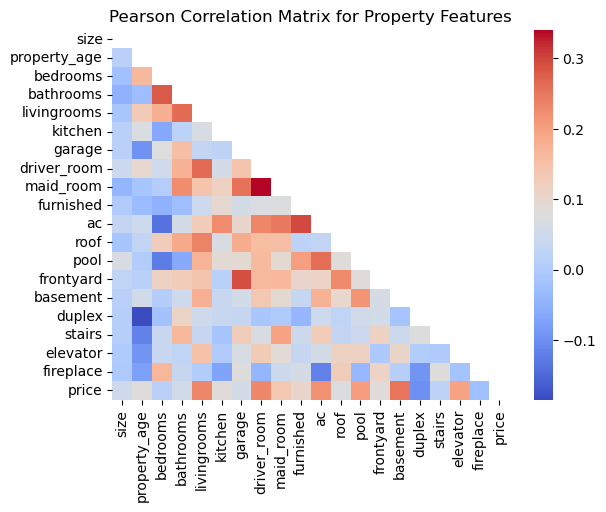

In [8]:
correlation_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix for Property Features')
plt.show()

## Data Cleaning:

Remove the `details` column.

In [9]:
df = df.drop(columns = 'details')

Prices under 30,000 are most likely monthly/daily prices or misentered values. These will be discarded.

In [10]:
df = df[df['price'] >= 30000]

Convert Arabic values to English.

In [11]:
df['city'] = df['city'].str.strip()
df['district'] = df['district'].str.strip()

df['city'] = df['city'].replace(
    {
    'الرياض': 'Riyadh',
    'جدة': 'Jeddah',
    'الدمام': 'Dammam',
    'الخبر': 'Khobar'
    }
)

df['front'] = df['front'].replace(
    {
    'شمال': 'North',
    'جنوب': 'South',
    'شرق': 'East',
    'غرب': 'West',
    'شمال غربي': 'Northwest',
    'شمال شرقي': 'Northeast',
    'جنوب شرقي': 'Southeast',
    'جنوب غربي': 'Southwest',
    '3 شوارع': 'Three Streets',
    '4 شوارع': 'Four Streets'
    }
)

Check the distribution of prices before removing outliers.

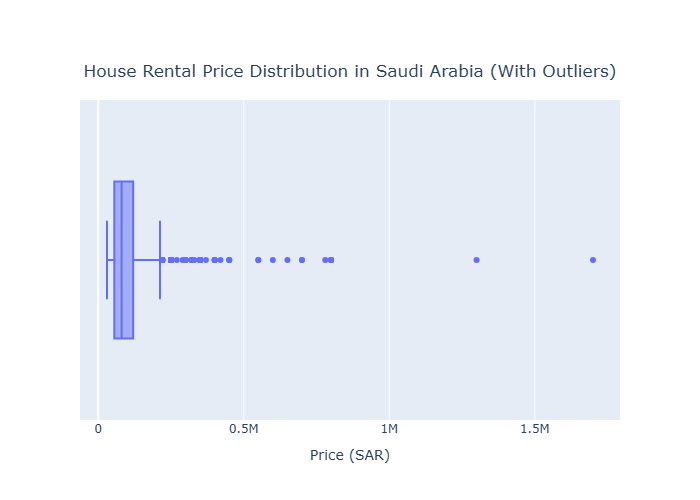

In [12]:
fig = px.box(
    df,
    x='price',
    title='House Rental Price Distribution in Saudi Arabia (With Outliers)'
)

fig.update_layout(
    title_x=0.5,
    title_y=0.87,
    xaxis_title='Price (SAR)'
)


# fig.show()

# Render as a static image since GitHub does not support interactive Plotly plots
fig.show(renderer="png")

Since the data is right-skewed, we will use the IQR method to remove the outliers.

In [13]:
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

Q1_size = df['size'].quantile(0.25)
Q3_size = df['size'].quantile(0.75)
IQR_size = Q3_size - Q1_size
lower_size = Q1_size - 1.5 * IQR_size
upper_size = Q3_size + 1.5 * IQR_size

# Define mask for outliers
outlier_mask = (
    (df['price'] < lower_price) | (df['price'] > upper_price) |
    (df['size'] < lower_size) | (df['size'] > upper_size)
)

# This dataframe only contains outliers
df_outliers = df[outlier_mask]

df_filtered = df[~outlier_mask]

print(f'Number of outliers: {df_outliers.shape[0]}')

Number of outliers: 172


Descriptive statistics of the data after filtering outliers.

In [14]:
df_filtered.describe()

,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,driver_room,maid_room,furnished,ac,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price
count,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0,1313.0
mean,342.814166,5.324448,4.883473,4.593298,2.213252,0.915461,0.852247,0.557502,0.784463,0.109673,0.538462,0.515613,0.151561,0.797411,0.04722,0.411272,0.803503,0.074638,0.168317,83379.097487
std,93.923793,7.457593,1.226974,0.701056,0.947674,0.278301,0.35499,0.496872,0.411351,0.3126,0.498708,0.499947,0.358732,0.402082,0.21219,0.492252,0.3975,0.262907,0.37429,39198.521905
min,125.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30000.0
25%,290.0,0.0,4.0,4.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,50000.0
50%,325.0,3.0,5.0,5.0,2.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,75000.0
75%,400.0,8.0,5.0,5.0,3.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,100000.0
max,600.0,36.0,7.0,5.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,212000.0


## Data Analysis and Visualization:

In [15]:
property_count_per_city = df['city'].value_counts().to_frame(name='Property Count')
property_count_per_city

,Property Count
city,
Riyadh,881
Jeddah,400
Dammam,121
Khobar,83


Jeddah is the most expensive city by average rental price. This might be due to the relatively small number of houses listed for rent compared to Riyadh.

In [16]:
avg_price_by_city = (
    df.groupby('city')['price']
    .mean()
    .sort_values(ascending=False)
    .to_frame(name='Mean Property Price')
    .astype(int)
)

avg_price_by_city

,Mean Property Price
city,
Jeddah,125358
Riyadh,97262
Khobar,75613
Dammam,73685


In [17]:
outliers_property_count_per_city = df_outliers['city'].value_counts().to_frame(name='Outlier Count')
outliers_property_count_per_city

,Outlier Count
city,
Riyadh,90
Jeddah,68
Khobar,8
Dammam,6


In [18]:
outliers_avg_price_by_city = (
    df_outliers.groupby('city')['price']
    .mean()
    .sort_values(ascending=False)
    .to_frame(name='Outlier Mean Price')
    .astype(int)
)

outliers_avg_price_by_city

,Outlier Mean Price
city,
Dammam,368333
Jeddah,251058
Riyadh,237944
Khobar,106250


Jeddah has the largest ratio of outliers. Although Dammam has the smallest ratio of outliers, the outlier houses in Dammam are the most expensive to rent on average.

In [19]:
outlier_ratio = (
    outliers_property_count_per_city.squeeze() / property_count_per_city.squeeze()
).sort_values(ascending=False).to_frame(name='Outlier Ratio')

outlier_ratio

,Outlier Ratio
city,
Jeddah,0.17
Riyadh,0.102157
Khobar,0.096386
Dammam,0.049587


### Plot 1: Distribution of Prices (Without Outliers)

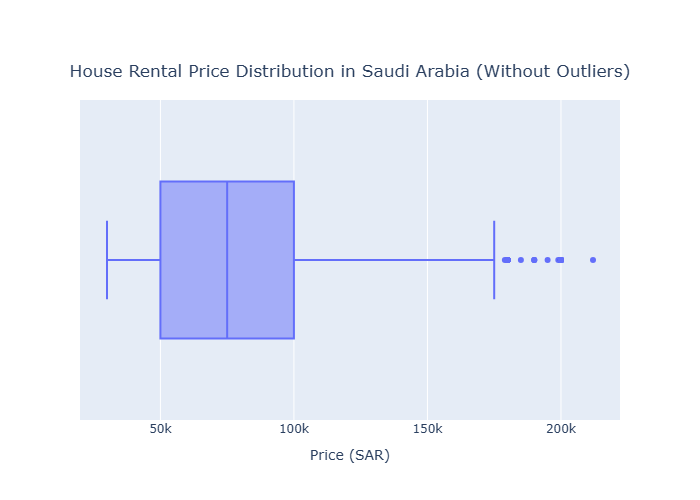

In [20]:
fig = px.box(
    df_filtered,
    x='price',
    title='House Rental Price Distribution in Saudi Arabia (Without Outliers)'
)

fig.update_layout(
    title_x=0.5,
    title_y=0.87,
    xaxis_title='Price (SAR)'
)

fig.show(renderer="png")

### Plot 2: Price Distribution by City

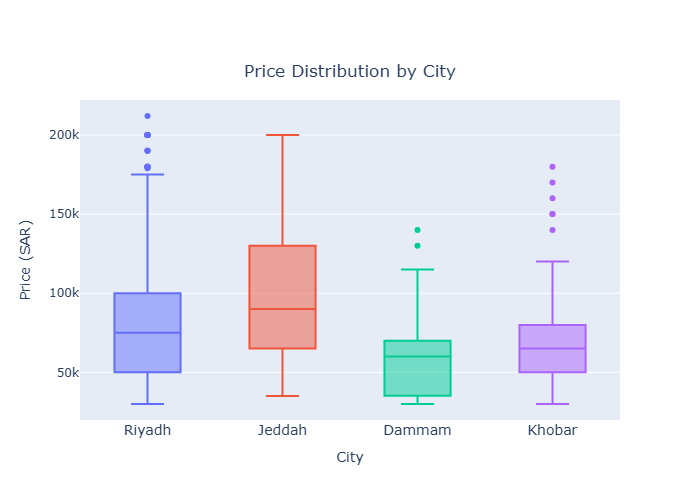

In [21]:
fig = px.box(
    df_filtered,
    x='city',
    y='price',
    color='city',
    title='Price Distribution by City'
)

fig.update_layout(
    title_x=0.5,
    title_y=0.87,
    xaxis_title='City',
    yaxis_title='Price (SAR)',
    showlegend=False,
    xaxis_tickfont=dict(size=14)
)

fig.show(renderer="png")

### Plot 3: Average Price by House Front

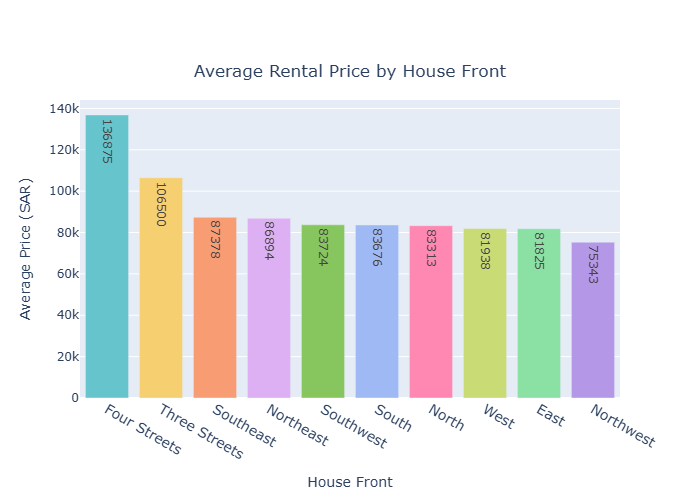

In [22]:
avg_price_by_front = (
    df_filtered
    .groupby('front')['price']
    .mean()
    .sort_values(ascending=False)
    .astype(int)
    .to_frame(name='Average Price')
)

fig = px.bar(
    avg_price_by_front.reset_index(),
    x='front',
    y='Average Price',
    color='front',
    orientation='v',
    title='Average Rental Price by House Front',
    text='Average Price',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='House Front',
    yaxis_title='Average Price (SAR)',
    title_y=0.87,
    showlegend=False,
    xaxis_tickfont=dict(size=14)
)

fig.show(renderer="png")

### Plot 4: Price Distribution by House Age

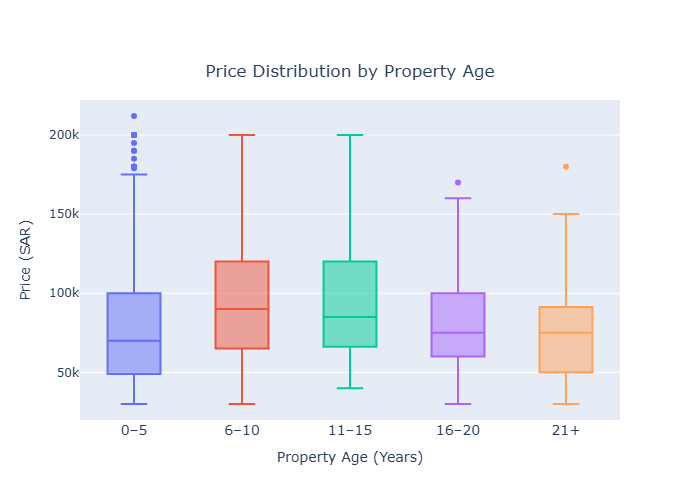

In [23]:
df_filtered = df_filtered.copy()

df_filtered['age_group'] = pd.cut(
    df_filtered['property_age'],
    bins=[0, 5, 10, 15, 20, float('inf')],
    labels=['0–5', '6–10', '11–15', '16–20', '21+'],
    include_lowest=True,
    right=True
)

fig = px.box(
    df_filtered,
    x='age_group',
    y='price',
    color='age_group',
    title='Price Distribution by Property Age',
    labels={'price': 'Price (SAR)', 'age_group': 'Property Age (Years)'},
    category_orders={'age_group': ['0–5', '6–10', '11–15', '16–20', '21+']}
)

fig.update_layout(title_x=0.5,
                  showlegend=False,
                  title_y=0.87,
                  xaxis_tickfont=dict(size=14))
fig.show(renderer="png")

## Price Prediction Using Extreme Gradient Boosting (XGBoost):

Since we have 176 districts, we will use K-Means Clustering to group the districts into few clusters based on average property price and size in the district.

In [25]:
# Separate features and target
X = df_filtered.drop(columns=['price','age_group'])
y = df_filtered['price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Initialize loop variables
best_r2 = -np.inf
best_rmse = np.inf
best_mape = np.inf
best_k = None
best_model = None
best_params = None

# Loop over different numbers of district clusters
for n_clusters in [5, 8, 10, 12, 15, 20]:
    # Compute district-level stats
    district_features = df_filtered.groupby('district')[['price', 'size']].mean()

    # Perform K-Means clustering on district features
    kmeans = KMeans(n_clusters=n_clusters, random_state=1)

    district_features['cluster'] = kmeans.fit_predict(district_features)
    cluster_map = district_features['cluster'].to_dict()

    # Map clusters to train/test sets
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    X_train_copy['district_cluster'] = X_train_copy['district'].map(cluster_map)
    X_test_copy['district_cluster'] = X_test_copy['district'].map(cluster_map)

    # Drop original 'district' and one-hot encode other categorical features
    X_train_copy = X_train_copy.drop(columns=['district'])
    X_test_copy = X_test_copy.drop(columns=['district'])

    X_train_copy = pd.get_dummies(X_train_copy, columns=['city', 'front'], drop_first=True)
    X_test_copy = pd.get_dummies(X_test_copy, columns=['city', 'front'], drop_first=True)
    X_test_copy = X_test_copy.reindex(columns=X_train_copy.columns, fill_value=0)

    # Grid search
    param_grid = {
        'n_estimators': [600],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.005, 0.01, 0.02],
        'subsample': [0.5, 0.8, 1],
        'colsample_bytree': [0.5, 0.8, 1]
    }

    scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mape': make_scorer(
        mean_absolute_percentage_error,
        greater_is_better=False
    )
    }

    model = XGBRegressor(n_jobs=-1, random_state=1)
    cv = KFold(n_splits=5, shuffle=True, random_state=1)
    grid_search = GridSearchCV(model, param_grid, cv=cv, scoring=scoring, refit='rmse', n_jobs=-1)
    grid_search.fit(X_train_copy, y_train)

    # Evaluate on test set
    y_pred = grid_search.best_estimator_.predict(X_test_copy)
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    print(f'Clusters: {n_clusters} | Best params: {grid_search.best_params_} | Average Validation RMSE: {-grid_search.best_score_:.0f} | Test RMSE: {rmse:.0f}')

    # Update the variables as you loop
    if rmse < best_rmse:
        best_r2 = r2
        best_rmse = rmse
        best_mape = mape
        best_k = n_clusters
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_

print('\n--- Best Result ---')
print('Best number of clusters:', best_k)
print('Best XGBoost parameters:', best_params)
print('Best test R²:', round(best_r2, 4))
print('Best test RMSE:', round(best_rmse), 'SAR')
print(f'Best test MAPE: {best_mape*100:.1f}%')

Clusters: 5 | Best params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 600, 'subsample': 0.5} | Average Validation RMSE: 23489 | Test RMSE: 21883
Clusters: 8 | Best params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 600, 'subsample': 0.8} | Average Validation RMSE: 23384 | Test RMSE: 21742
Clusters: 10 | Best params: {'colsample_bytree': 0.5, 'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 600, 'subsample': 1} | Average Validation RMSE: 23855 | Test RMSE: 21987
Clusters: 12 | Best params: {'colsample_bytree': 0.5, 'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 600, 'subsample': 1} | Average Validation RMSE: 24360 | Test RMSE: 22434
Clusters: 15 | Best params: {'colsample_bytree': 0.5, 'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 600, 'subsample': 1} | Average Validation RMSE: 24561 | Test RMSE: 22508
Clusters: 20 | Best params: {'colsample_bytree': 0.5, 'learning_rate': 0.02, 'max_depth'

The model was trained on 1050 samples after the removal of duplicates and outliers. With a dataset this small, there is limited room for significant improvement in model performance through additional feature engineering.